# EDA - Engagements effect on completion of courses

## Introduction
This Exploratory Data Analysis (EDA) aims to understand what it means to be engaged in a course and then what impact being engaged has on completing a course. The course could be considered as a fill in for any project or ambition that one might understake where engagement is necesarry to achieve said goal. 

## Hypothesis
Being engaged results in marketably improved chances of completing a course

## Data Prep and cleaning

### Data Prep


The data set that will be used for this data analysis is one from Kaggle that measured 10000 students of online courses. The data itself will be presented below but first I will be importing the necessary libraries to conduct the analysis as well as the data itself

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download("muqaddasejaz/online-course-engagement-dataset", path="online_course_engagement_data.csv")

print("Path to dataset files:", path)

Path to dataset files: /Users/ailinalvarez/.cache/kagglehub/datasets/muqaddasejaz/online-course-engagement-dataset/versions/1/online_course_engagement_data.csv


### Data Cleaning

Now we read the data to see if there are any specific data points that might be odd or should not belong. For example a test score of above 100 would be impossible if the test score range was 0-100. I will also look for any null values or other inconsistencies

In [3]:
df = pd.read_csv(path)
df.sample(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UserID                 9000 non-null   int64  
 1   CourseCategory         9000 non-null   object 
 2   TimeSpentOnCourse      9000 non-null   float64
 3   NumberOfVideosWatched  9000 non-null   int64  
 4   NumberOfQuizzesTaken   9000 non-null   int64  
 5   QuizScores             9000 non-null   float64
 6   CompletionRate         9000 non-null   float64
 7   DeviceType             9000 non-null   int64  
 8   CourseCompletion       9000 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 632.9+ KB


,UserID,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4498.894556,50.163822,10.024667,5.090556,74.706028,50.340146,0.500667,0.396444
std,2596.849433,28.491750,6.029878,3.157762,14.378383,28.950977,0.500027,0.489186
min,1.000000,1.005230,0.000000,0.000000,50.005119,0.009327,0.000000,0.000000
25%,2251.750000,25.440548,5.000000,2.000000,62.283451,25.653614,0.000000,0.000000
50%,4483.500000,49.818417,10.000000,5.000000,74.743294,50.264124,1.000000,0.000000
75%,6751.250000,75.069924,15.000000,8.000000,87.022663,75.572493,1.000000,1.000000
max,9000.000000,99.992558,20.000000,10.000000,99.994984,99.979711,1.000000,1.000000


Nothing out of the ordinary in terms of ranges that would suggest issues with the data.

In [4]:
df.isnull().sum()

UserID                   0
CourseCategory           0
TimeSpentOnCourse        0
NumberOfVideosWatched    0
NumberOfQuizzesTaken     0
QuizScores               0
CompletionRate           0
DeviceType               0
CourseCompletion         0
dtype: int64

No Null values

In [5]:
print(df['UserID'].nunique())

8123


So there are some duplicative values of UserID's considering the total length of the DF is 9000

In [6]:
duplicate_ids = df[['CourseCategory']].groupby(df['UserID']).count().sort_values(by='CourseCategory', ascending=False).query("`CourseCategory` > 1")
print(duplicate_ids)

        CourseCategory
UserID                
9000                 2
3615                 2
3620                 2
1392                 2
5789                 2
...                ...
8552                 2
543                  2
499                  2
4168                 2
8696                 2

[877 rows x 1 columns]


We can see that there were no UserIDs duplicated more than one time. Considering that having multiple entries of the same user might effect the quality of the results of this analysis I will be removing these duplicates. This is after considering that the cut is quite significant (almost 10% of the total population of the data) but the data set remains sufficiently large in my estimation that data quality is a higher priority

In [7]:
df = df.drop_duplicates(subset=['UserID'])

In [8]:
print(duplicate_ids)

        CourseCategory
UserID                
9000                 2
3615                 2
3620                 2
1392                 2
5789                 2
...                ...
8552                 2
543                  2
499                  2
4168                 2
8696                 2

[877 rows x 1 columns]


Now that the duplicate Users are removed we can proceed with the analysis

## EDA

### Main Exploration

Seeing the data set it would be interesting to first see if there is any specific activity that correlates to course completion. The only outlier that might want to be fixed first is the CourseCategory column as it contains objects. Since these are non operable I will convert them using dummies to include a look if there is a correlation between which course is selected and course completion

#### Data Point Correlation

In [9]:
print(df['CourseCategory'].unique())

['Health' 'Arts' 'Science' 'Programming' 'Business']


In [10]:
dummies_df = pd.get_dummies(df)
dummies_df.sample(2)

,UserID,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion,CourseCategory_Arts,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
4100,104,30.844162,12,7,77.311806,55.514785,1,1,False,True,False,False,False
5836,1063,55.254128,15,8,89.864282,77.732503,1,1,False,False,False,False,True


In [11]:
print(dummies_df.columns)

Index(['UserID', 'TimeSpentOnCourse', 'NumberOfVideosWatched',
       'NumberOfQuizzesTaken', 'QuizScores', 'CompletionRate', 'DeviceType',
       'CourseCompletion', 'CourseCategory_Arts', 'CourseCategory_Business',
       'CourseCategory_Health', 'CourseCategory_Programming',
       'CourseCategory_Science'],
      dtype='object')


Now that this is done we can go ahead and get a heat map with the correlation of the columns

<Axes: >

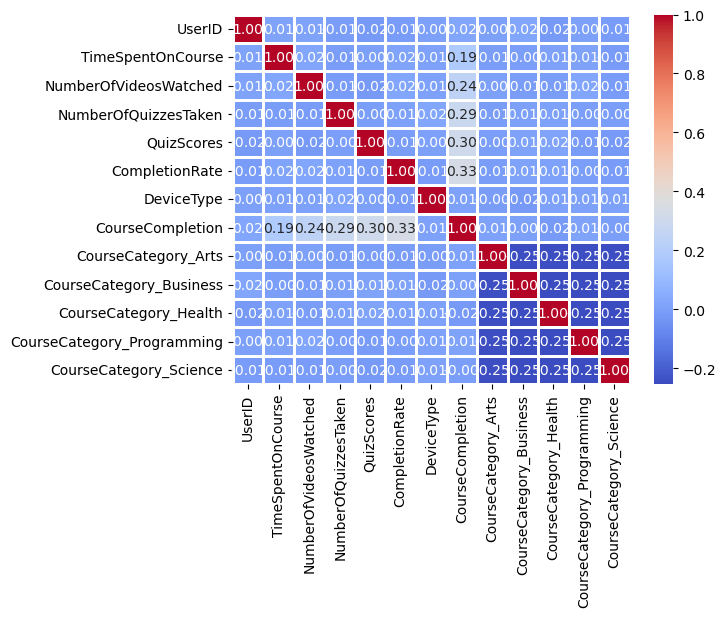

In [12]:
corr_matrix = dummies_df.corr(method="spearman")
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.75, fmt='.2f', annot=True)

There is not much in terms of obvious conclusions to draw from this but there are some interesting take aways:
* There does not seem to be any course that is "easier" for students to complete. This however would more likely be due to the source of the data specifically aiming for 50% completion rate, and with this data it seems that this target was applied for each category and not just overall.
* There does not seem to be any real correlation between any metric and quizz score, seemingly while it might have an effect on the efficacy of the class these quizzes do not seem be a good correlary to other data points
* While time spent on the course has a clearly lower correlation than CompletionRate (almost half the correlation score), there does not seem to be any data that is strongly correlated with CourseCompletion. As such we would be better of seeing these data points in aggregate as a sign of engagement rather than any single point being representative

#### Data Distribution by Course Completion

/var/folders/b2/lv6qp5j57qsg2gyqh4np3lgw0000gn/T/ipykernel_37957/3256267704.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No', 'Yes'])
/var/folders/b2/lv6qp5j57qsg2gyqh4np3lgw0000gn/T/ipykernel_37957/3256267704.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No', 'Yes'])
/var/folders/b2/lv6qp5j57qsg2gyqh4np3lgw0000gn/T/ipykernel_37957/3256267704.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No', 'Yes'])
/var/folders/b2/lv6qp5j57qsg2gyqh4np3lgw0000gn/T/ipykernel_37957/3256267704.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels

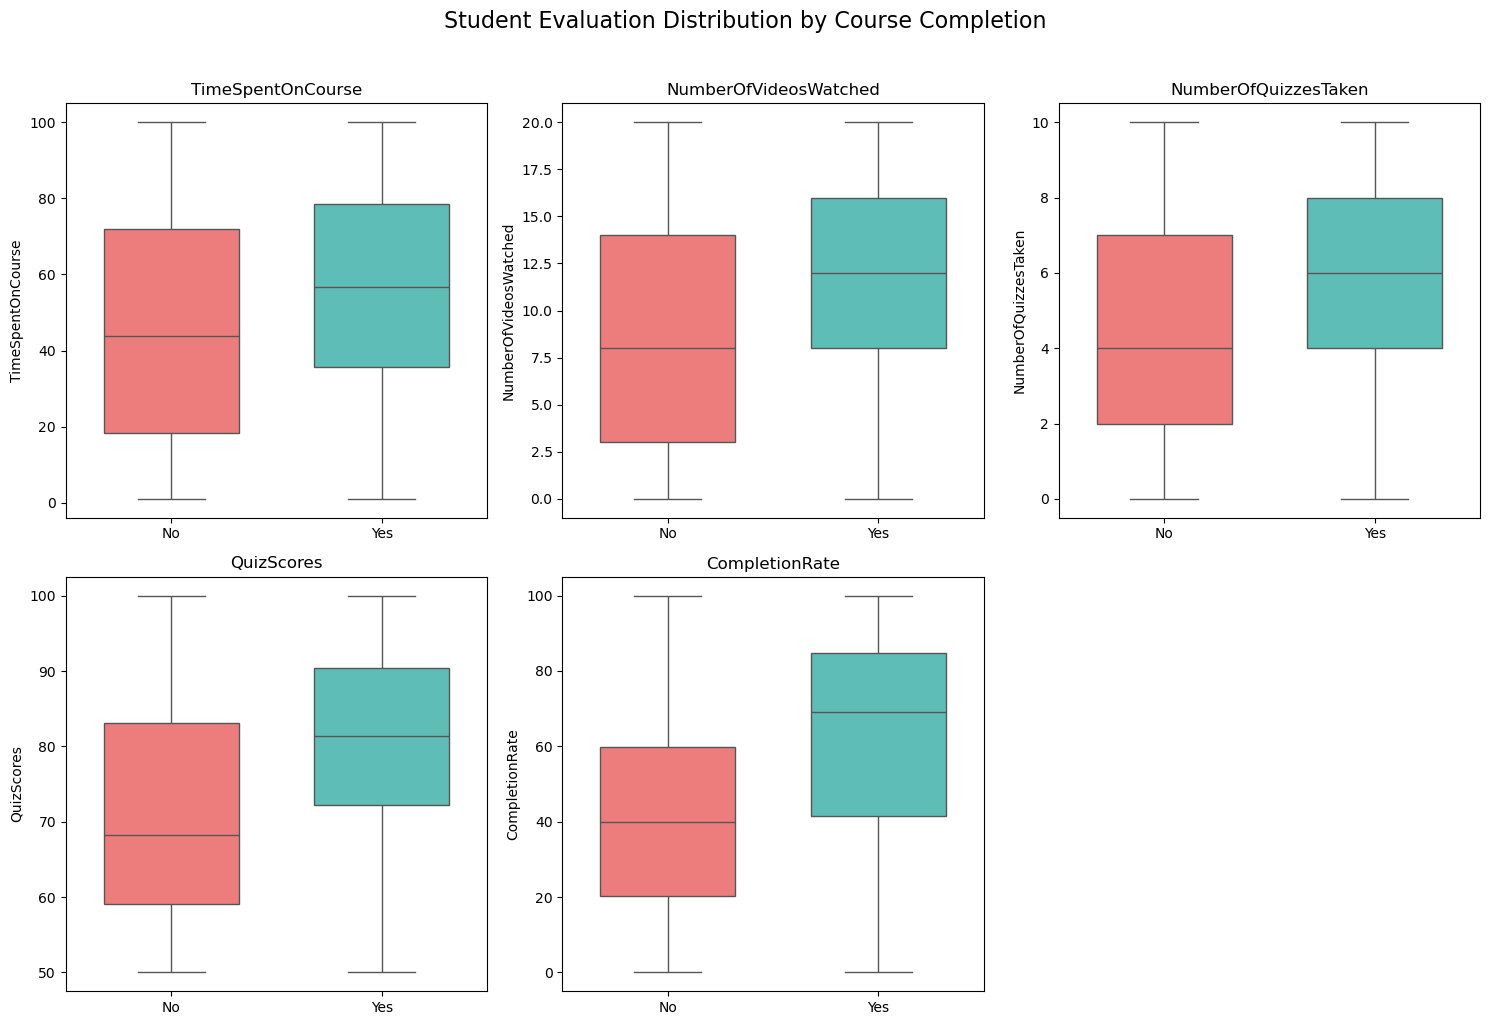

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, column in enumerate(dummies_df.columns[1:6]):  # Limit to 'TimeSpent', 'VideosWatched', 'QuizzesTaken', 'QuizScores', 'CompletionRate', 'DeviceType'
    sns.boxplot(
        data=dummies_df, 
        x='CourseCompletion', 
        y=column, 
        hue='CourseCompletion',
        gap=0.2,
        ax=axes[idx],
        palette=['#FF6B6B', '#4ECDC4']
    )
    
    formatted_column = column.replace('_', ' ').replace('CourseCategory', 'Category')
    axes[idx].set_title(formatted_column)
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['No', 'Yes'])
    axes[idx].legend().remove()

    # Hide any unused subplots
    for idx in range(len(dummies_df.columns[1:6]), len(axes)):
        axes[idx].set_visible(False)


plt.suptitle('Student Evaluation Distribution by Course Completion', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Here we can start to see a pattern. While no individual data point has a clear correlation with CourseCompletion we can see that in aggregate all of the indicators are elevated for the students that completed the course compared to those that did not finish the course. 

### Defining Engagement

Based the average score for each data point we can define a highly engaged student to be someone that has above average on all points. This would mean:
* TimeSpentOnCourse >= 50
* NumberOfVideosWatched > 10
* NumbersOfQuizzesTaken >= 5
* QuizScores >= 75
* CompletionRate >= 51

In [14]:
HE_students = dummies_df.query('`TimeSpentOnCourse` >= 50 & `NumberOfVideosWatched` > 10 & `NumberOfQuizzesTaken` >= 5 & `QuizScores` >= 75 & `CompletionRate` >= 51')

In [15]:
HE_students.describe()

,UserID,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,4373.511706,73.644265,15.301003,7.541806,87.065020,77.086927,0.531773,0.983278
std,2561.605764,14.543767,2.931494,1.757274,7.222368,14.007799,0.499826,0.128444
min,4.000000,50.277900,11.000000,5.000000,75.006348,51.052902,0.000000,0.000000
25%,2216.000000,60.926767,13.000000,6.000000,81.063045,64.808314,0.000000,1.000000
50%,4438.000000,72.508806,15.000000,8.000000,87.100025,78.628962,1.000000,1.000000
75%,6727.000000,85.647353,18.000000,9.000000,92.574716,89.070581,1.000000,1.000000
max,8948.000000,99.862531,20.000000,10.000000,99.969794,99.979711,1.000000,1.000000


In [16]:
c_percent = len(HE_students.query('`CourseCompletion` == 1')) / len(HE_students) * 100
print(f"Percentage of HE students that complete the course: {c_percent:.2f}%")

Percentage of HE students that complete the course: 98.33%


We can see here that while a random student picked has about a 39,64% chance of completing the course, the course completion chance for a student picked that can be classified as highly engaged is more than double at 98,33%

## Conclusion

In this analysis we looked at the correlative effect of certain learning techniques on course completion for an online course. From the data we could learn that while any single data point on a student cannot give an accurate prediction of whether or not that student will complete the course.

We also learned that while seprate these data points might not have high correlative value to course completion, in aggregate they can be used to define the concept of being highly engaged in the course. When looking at engagement then, there is a clear disctinction between the average student and a highly engaged student. 